# Neural Network Comparison
The Neural Networks (particulary ANN and CNN) used in this project aim to cateogrize images into categories.

In [2]:
# import CIFAR-10 dataset and all necessary packages
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


# Import CIFAR-10 dataset
cifar10 = tf.keras.datasets.cifar10
(train_xs, train_ys), (test_xs, test_ys) = cifar10.load_data()
class_names = ["Airplane","Automobile","Bird","Cat","Deer","Dog","Frog","Horse","Ship","Truck"]


# Printing the class names
for i, class_name in enumerate(class_names, start=0):
    print(f"Class {i}: {class_name}")

170498071/170498071 [==============================] - 3s 0us/step
Class 0: Airplane
Class 1: Automobile
Class 2: Bird
Class 3: Cat
Class 4: Deer
Class 5: Dog
Class 6: Frog
Class 7: Horse
Class 8: Ship
Class 9: Truck


# Data Exploration

In [6]:
# basic information of dataset
print("Total number of images in the train and test datasets:", len(train_xs), len(test_xs))
print("Size of each image:", train_xs[5].shape)
print("Number of labels:", np.unique(train_ys))

Total number of images in the train and test datasets: 50000 10000
Size of each image: (32, 32, 3)
[7]
Number of labels: [0 1 2 3 4 5 6 7 8 9]


25 Training Sample Images


<ipython-input-4-c90d67c5f744>:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xlabel(class_names[int(train_ys[i])])


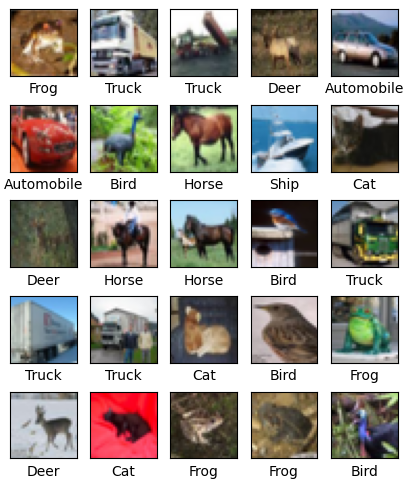

25 Training Sample Images


<ipython-input-4-c90d67c5f744>:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xlabel(class_names[int(test_ys[i])])


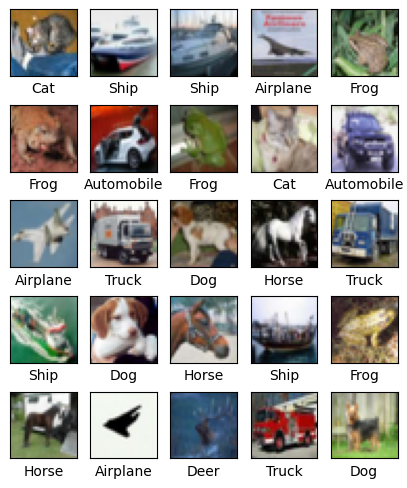

In [4]:
# display train sample images
print("25 Training Sample Images")
plt.figure(figsize=(5,6))
for i in range(25):
  plt.subplot(5, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_xs[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[int(train_ys[i])])
plt.show()

# display testing sample images
print("25 Training Sample Images")
plt.figure(figsize=(5,6))
for i in range(25):
  plt.subplot(5, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(test_xs[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[int(test_ys[i])])
plt.show()

# Data Preprocessing

[7]


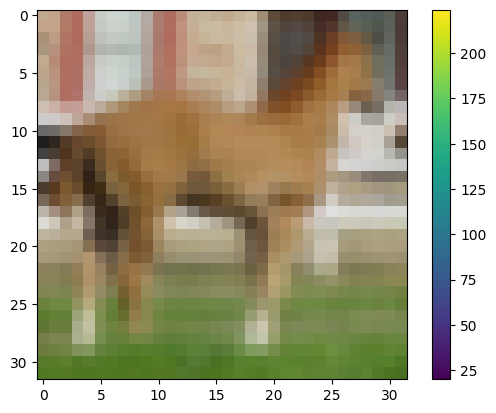

In [7]:
# verifying images
plt.imshow(train_xs[654])
plt.colorbar()
print(train_ys[654])

In [8]:
# normalize pixel vlaues + resize images
train_xs = train_xs / 255
test_xs = test_xs / 255

# ANN Model Architecture Design

In [9]:
# build ANN for image classification. 3 iterations: additional dense layers were added, epochs were added and removed
# create model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

# declaring the optimizer, loss function, and evaluation metrics
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# train neural network model
history = model.fit(train_xs, train_ys, epochs = 5, validation_data=(test_xs, test_ys))
# consider adding verbose?

# validating the model with the testing data set
train_loss = model.evaluate(train_xs, train_ys)
test_loss = model.evaluate(test_xs, test_ys)

# print out the loss and accuracy for train and test data set
print("Training Loss:", train_loss)
print("Testing Loss:", test_loss)


Epoch 1/5
1563/1563 [==============================] - 17s 10ms/step - loss: 1.8887 - accuracy: 0.3093 - val_loss: 1.7562 - val_accuracy: 0.3665
Epoch 2/5
1563/1563 [==============================] - 11s 7ms/step - loss: 1.7315 - accuracy: 0.3755 - val_loss: 1.6693 - val_accuracy: 0.4009
Epoch 3/5
1563/1563 [==============================] - 16s 10ms/step - loss: 1.6776 - accuracy: 0.3960 - val_loss: 1.6670 - val_accuracy: 0.4036
Epoch 4/5
1563/1563 [==============================] - 12s 7ms/step - loss: 1.6496 - accuracy: 0.4099 - val_loss: 1.6755 - val_accuracy: 0.4015
Epoch 5/5
313/313 [==============================] - 1s 3ms/step - loss: 1.6113 - accuracy: 0.4272
Training Loss: [1.5925661325454712, 0.42890000343322754]
Testing Loss: [1.6112521886825562, 0.42719998955726624]


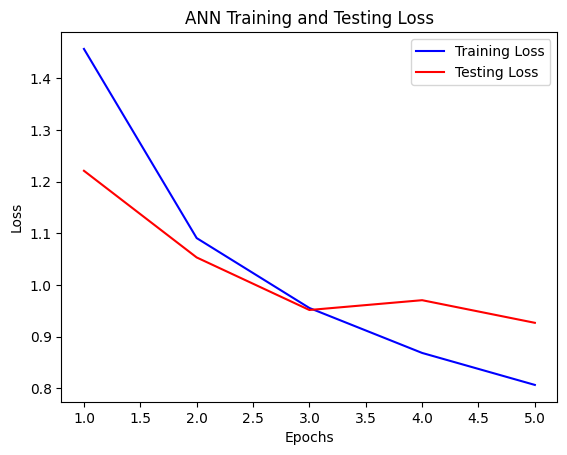

In [11]:
# plot the loss curves for train and test datasets
training_loss = history.history['loss']
testing_loss = history.history['val_loss']

epochs = range(1, len(training_loss) + 1)

plt.plot(epochs, training_loss, 'b', label='Training Loss')
plt.plot(epochs, testing_loss, 'r', label='Testing Loss')
plt.title('ANN Training and Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [29]:
# prediction
classifications = model.predict(test_xs)
probs = classifications[654].round(4)
print(class_names[int(test_ys[654])])
print(class_names[np.argmax(probs)])

313/313 [==============================] - 1s 2ms/step
Truck
Truck


<ipython-input-29-50fad04f6f64>:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(class_names[int(test_ys[654])])


# CNN Model Architecture Design

In [13]:
# build CNN for image classification. 3 iterations: kernel size changed, input size updated, epochs increased
# create model
model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(64, (2,2), activation='relu', input_shape=(32, 32, 3),padding='valid'),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Conv2D(64, (2,2), activation='relu',padding='valid'),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

# declaring the optimizer, loss function, and evaluation metrics
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# train neural network model
history = model.fit(train_xs, train_ys, epochs = 10, validation_data=(test_xs, test_ys))

# validating the model with the testing data set
train_loss = model.evaluate(train_xs, train_ys)
test_loss = model.evaluate(test_xs, test_ys)

# print out the loss and accuracy for train and test data set
print("Training Loss:", train_loss)
print("Testing Loss:", test_loss)

Epoch 1/10
1563/1563 [==============================] - 13s 7ms/step - loss: 1.3987 - accuracy: 0.5015 - val_loss: 1.1242 - val_accuracy: 0.6002
Epoch 2/10
1563/1563 [==============================] - 11s 7ms/step - loss: 1.0608 - accuracy: 0.6296 - val_loss: 0.9992 - val_accuracy: 0.6514
Epoch 3/10
1563/1563 [==============================] - 10s 6ms/step - loss: 0.9334 - accuracy: 0.6736 - val_loss: 1.0408 - val_accuracy: 0.6329
Epoch 4/10
1563/1563 [==============================] - 10s 7ms/step - loss: 0.8491 - accuracy: 0.7040 - val_loss: 0.8947 - val_accuracy: 0.6926
Epoch 5/10
1563/1563 [==============================] - 11s 7ms/step - loss: 0.7841 - accuracy: 0.7270 - val_loss: 0.8887 - val_accuracy: 0.6913
Epoch 6/10
1563/1563 [==============================] - 11s 7ms/step - loss: 0.7236 - accuracy: 0.7448 - val_loss: 0.8864 - val_accuracy: 0.6956
Epoch 7/10
1563/1563 [==============================] - 12s 7ms/step - loss: 0.6743 - accuracy: 0.7639 - val_loss: 0.9149 - val_ac

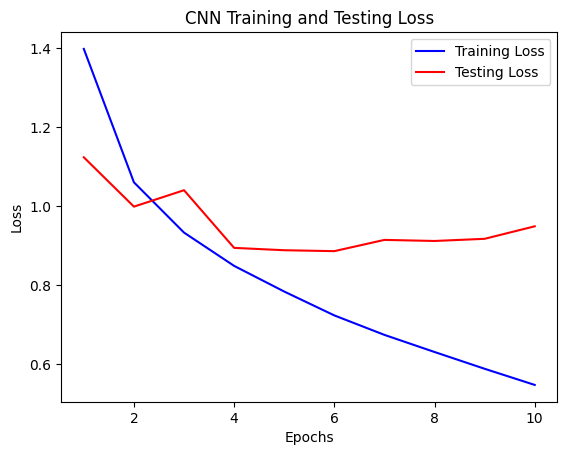

In [14]:
# plot the loss curves for train and test datasets
training_loss = history.history['loss']
testing_loss = history.history['val_loss']

epochs = range(1, len(training_loss) + 1)

plt.plot(epochs, training_loss, 'b', label='Training Loss')
plt.plot(epochs, testing_loss, 'r', label='Testing Loss')
plt.title('CNN Training and Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
# prediction
classifications = model.predict(test_xs)
probs = classifications[654].round(4)
print(class_names[int(test_ys[654])])
print(class_names[np.argmax(probs)])

313/313 [==============================] - 1s 2ms/step
Truck
Truck


<ipython-input-28-74756bfff0ee>:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(class_names[int(test_ys[654])])
